In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/transactions.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Transaction_ID,Payment_Method,Bank,Device,Location,Time,Amount,Transaction_Status
0,TXN100000,Net Banking,Kotak,Android,Pune,2026-01-23 21:48:00,146.92,Success
1,TXN100001,UPI,SBI,Android,Hyderabad,2026-01-27 02:11:00,753.60,Success
2,TXN100002,Net Banking,SBI,Web,Coimbatore,2026-02-19 06:06:00,1721.81,Success
3,TXN100003,UPI,ICICI,Android,Hyderabad,2026-02-13 19:00:00,937.07,Failed
4,TXN100004,Credit Card,ICICI,Android,Chennai,2026-01-06 07:36:00,819.73,Success


In [ ]:
# Get information about the DataFrame, including data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Transaction_ID      10000 non-null  object 
 1   Payment_Method      10000 non-null  object 
 2   Bank                10000 non-null  object 
 3   Device              10000 non-null  object 
 4   Location            10000 non-null  object 
 5   Time                10000 non-null  object 
 6   Amount              10000 non-null  float64
 7   Transaction_Status  10000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 625.1+ KB


In [ ]:
# Convert 'Time' column to datetime objects
df['Time'] = pd.to_datetime(df['Time'])

# Display the DataFrame info again to confirm the data type change
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      10000 non-null  object        
 1   Payment_Method      10000 non-null  object        
 2   Bank                10000 non-null  object        
 3   Device              10000 non-null  object        
 4   Location            10000 non-null  object        
 5   Time                10000 non-null  datetime64[ns]
 6   Amount              10000 non-null  float64       
 7   Transaction_Status  10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 625.1+ KB


In [ ]:
# Check unique values and their counts in 'Transaction_Status'
df['Transaction_Status'].value_counts()

,count
Transaction_Status,
Success,9162
Failed,838


In [ ]:
# Calculate overall failure rate
failed_transactions = df[df['Transaction_Status'] == 'Failed'].shape[0]
total_transactions = df.shape[0]
overall_failure_rate = (failed_transactions / total_transactions) * 100

print(f"Overall Failure Rate: {overall_failure_rate:.2f}%")

Overall Failure Rate: 8.38%


In [ ]:
# Create a new column 'Is_Failed' (1 for failed, 0 for success)
df['Is_Failed'] = df['Transaction_Status'].apply(lambda x: 1 if x == 'Failed' else 0)

# Display the head of the DataFrame with the new column
display(df.head())

,Transaction_ID,Payment_Method,Bank,Device,Location,Time,Amount,Transaction_Status,Is_Failed
0,TXN100000,Net Banking,Kotak,Android,Pune,2026-01-23 21:48:00,146.92,Success,0
1,TXN100001,UPI,SBI,Android,Hyderabad,2026-01-27 02:11:00,753.60,Success,0
2,TXN100002,Net Banking,SBI,Web,Coimbatore,2026-02-19 06:06:00,1721.81,Success,0
3,TXN100003,UPI,ICICI,Android,Hyderabad,2026-02-13 19:00:00,937.07,Failed,1
4,TXN100004,Credit Card,ICICI,Android,Chennai,2026-01-06 07:36:00,819.73,Success,0


In [ ]:
# Calculate success rates across banks
bank_success_rates = df.groupby('Bank')['Is_Failed'].mean()
bank_success_rates = (1 - bank_success_rates) * 100

print("Success Rates by Bank:")
display(bank_success_rates.sort_values(ascending=False))

# Calculate success rates across payment methods
payment_method_success_rates = df.groupby('Payment_Method')['Is_Failed'].mean()
payment_method_success_rates = (1 - payment_method_success_rates) * 100

print("\nSuccess Rates by Payment Method:")
display(payment_method_success_rates.sort_values(ascending=False))

Success Rates by Bank:


,Is_Failed
Bank,
Bank of Baroda,93.308081
Axis,92.545710
Kotak,92.276830
HDFC,92.276657
SBI,91.680720
ICICI,91.287636
PNB,89.281768
Yes Bank,89.245983



Success Rates by Payment Method:


,Is_Failed
Payment_Method,
Debit Card,92.643052
UPI,91.758475
Credit Card,91.363102
Net Banking,90.604027
Wallet,90.142857


In [ ]:
# Extract the hour from the 'Time' column
df['Hour'] = df['Time'].dt.hour

# Calculate failure rates by hour of the day
failure_rates_by_hour = df.groupby('Hour')['Is_Failed'].mean() * 100

print("Failure Rates by Hour of Day:")
display(failure_rates_by_hour.sort_values(ascending=False).head())

Failure Rates by Hour of Day:


,Is_Failed
Hour,
20,13.551402
11,11.519608
21,11.290323
0,9.976798
15,9.879518


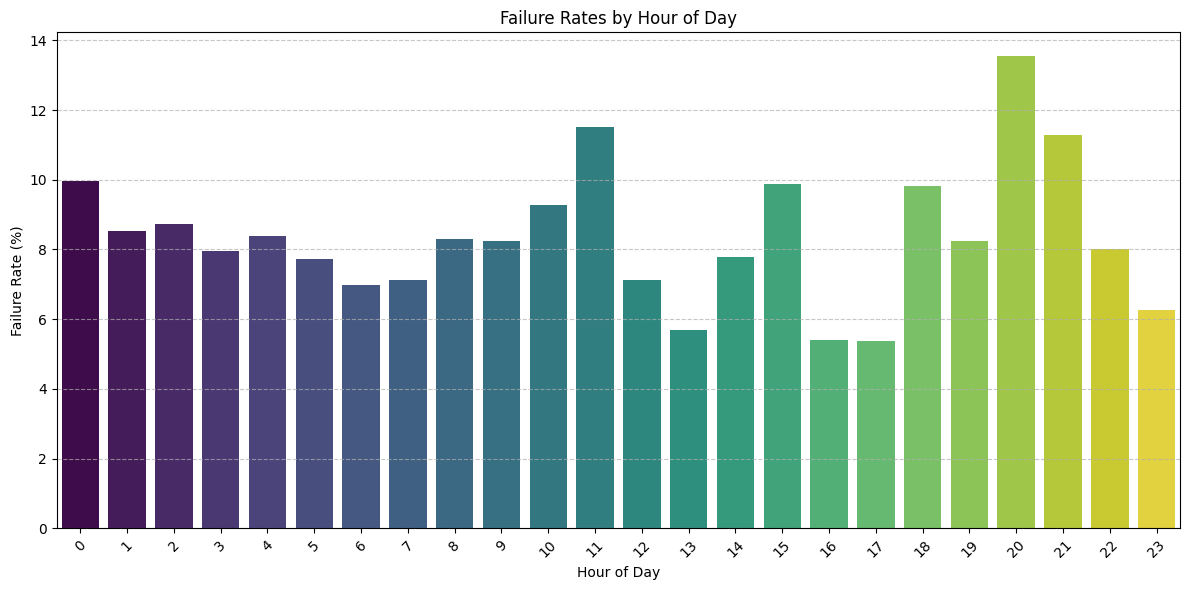

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize failure rates by hour
plt.figure(figsize=(12, 6))
sns.barplot(x=failure_rates_by_hour.index, y=failure_rates_by_hour.values, palette='viridis', hue=failure_rates_by_hour.index, legend=False)
plt.title('Failure Rates by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate failure rates by device type
failure_rates_by_device = df.groupby('Device')['Is_Failed'].mean() * 100

print("Failure Rates by Device Type:")
display(failure_rates_by_device.sort_values(ascending=False))

Failure Rates by Device Type:


,Is_Failed
Device,
Web,8.832613
iOS,8.361582
Android,8.260566


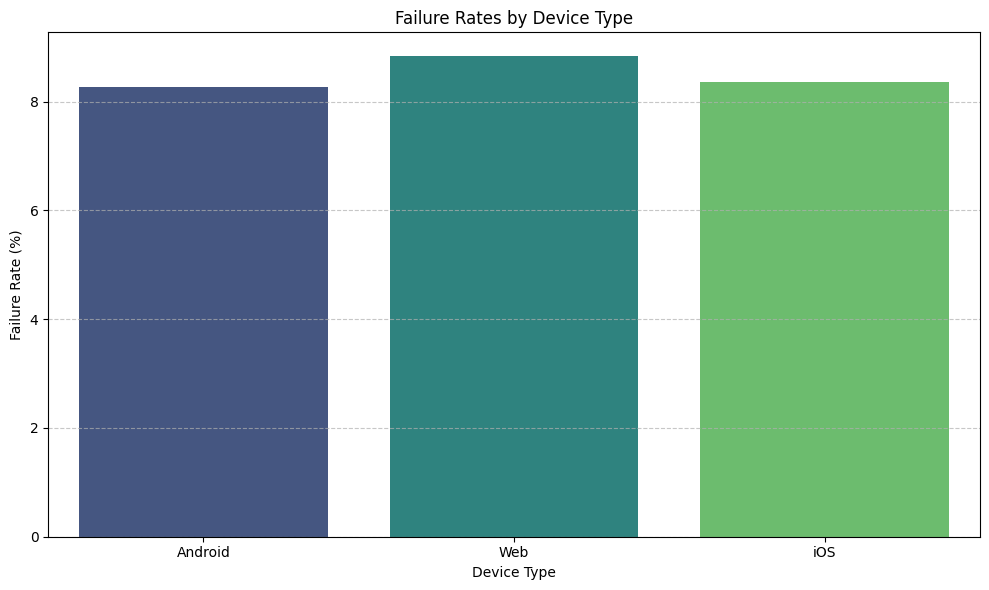

In [ ]:
# Visualize failure rates by device type
plt.figure(figsize=(10, 6))
sns.barplot(x=failure_rates_by_device.index, y=failure_rates_by_device.values, palette='viridis', hue=failure_rates_by_device.index, legend=False)
plt.title('Failure Rates by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Failure Rate (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate failure rates by transaction amount
# Create bins for transaction amounts
# Ensure 'Amount_Bin' is created if not already present
if 'Amount_Bin' not in df.columns:
    # Determine appropriate bins. Using qcut for more balanced distribution if data is skewed.
    # Alternatively, use fixed bins as in the previous thought, but qcut often works better for EDA before modeling.
    # For this task, let's use fixed bins first for direct comparison.
    df['Amount_Bin'] = pd.cut(df['Amount'], bins=5, labels=[f'Bin {i+1}' for i in range(5)])

# Calculate failure rates by amount bin
failure_rates_by_amount = df.groupby('Amount_Bin', observed=False)['Is_Failed'].mean() * 100

print("Failure Rates by Transaction Amount Bins:")
display(failure_rates_by_amount)

Failure Rates by Transaction Amount Bins:


,Is_Failed
Amount_Bin,
0-1,8.346972
1-2,9.947644
2-3,12.000000
3-4,0.000000
4-5,0.000000


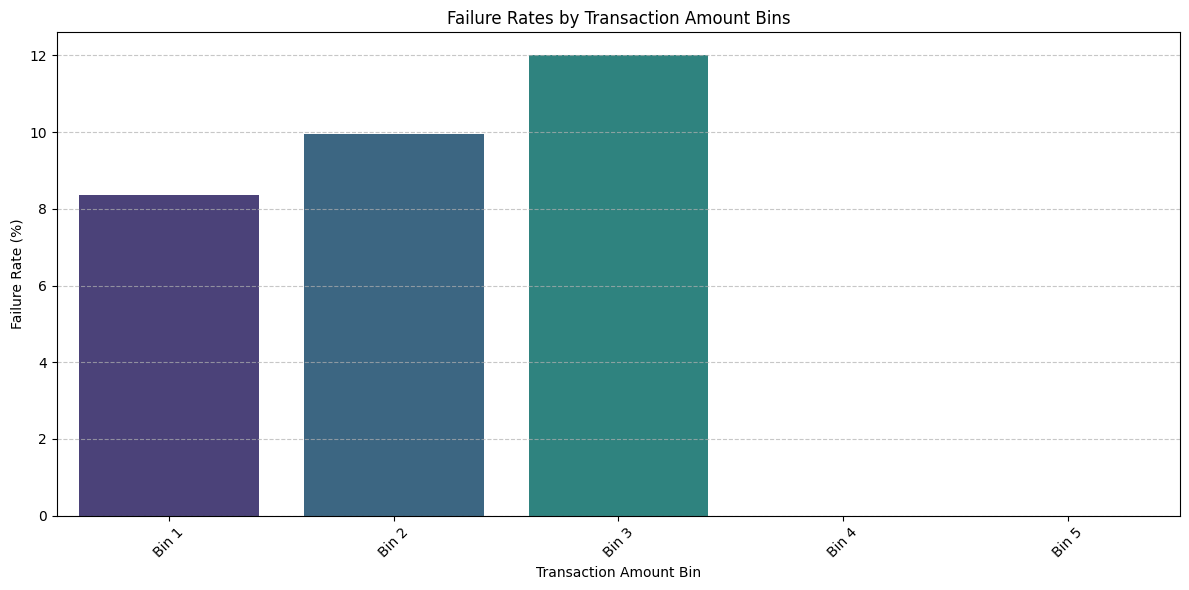

In [ ]:
# Visualize failure rates by transaction amount bin
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(x=failure_rates_by_amount.index, y=failure_rates_by_amount.values, palette='viridis', hue=failure_rates_by_amount.index, legend=False)
plt.title('Failure Rates by Transaction Amount Bins')
plt.xlabel('Transaction Amount Bin')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# --- Data Preparation for Random Forest Model ---

# Select features (X) and target (y)
features = ['Payment_Method', 'Bank', 'Device', 'Hour', 'Amount', 'Amount_Bin']
X = df[features]
y = df['Is_Failed']

# Handle categorical features using one-hot encoding
X = pd.get_dummies(X, columns=['Payment_Method', 'Bank', 'Device', 'Amount_Bin'], drop_first=True)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Data preparation for Random Forest model complete. Features and target split into training and testing sets.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Data preparation for Random Forest model complete. Features and target split into training and testing sets.
Training set shape: (7000, 19)
Testing set shape: (3000, 19)


In [ ]:
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [ ]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- Model Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


--- Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      2749
           1       0.12      0.01      0.02       251

    accuracy                           0.91      3000
   macro avg       0.52      0.50      0.49      3000
weighted avg       0.85      0.91      0.87      3000


Confusion Matrix:
[[2727   22]
 [ 248    3]]

ROC AUC Score: 0.4850


In [ ]:
# Get feature importances from the trained Random Forest model
feature_importances = pd.Series(rf_classifier.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Top 10 Feature Importances:")
display(feature_importances.head(10))

Top 10 Feature Importances:


,0
Amount,0.472622
Hour,0.284937
Device_iOS,0.030423
Device_Web,0.025567
Payment_Method_UPI,0.025263
Bank_SBI,0.018541
Bank_HDFC,0.018184
Bank_ICICI,0.017633
Payment_Method_Net Banking,0.016256
Payment_Method_Debit Card,0.015904


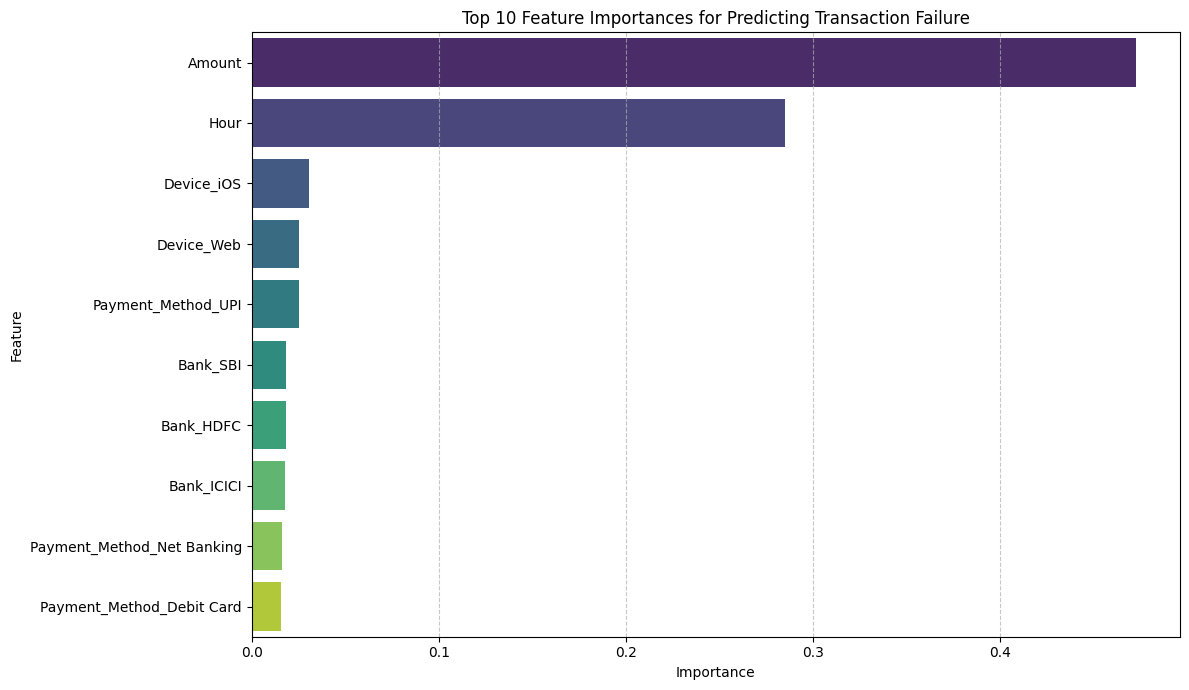

In [ ]:
# Visualize feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x=feature_importances.head(10).values, y=feature_importances.head(10).index, palette='viridis', hue=feature_importances.head(10).index, legend=False)
plt.title('Top 10 Feature Importances for Predicting Transaction Failure')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

Random Forest Classifier trained successfully!


In [ ]:
# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)
y_pred_proba = rf_classifier.predict_proba(X_test)[:, 1]

# Evaluate the model
print("\n--- Model Evaluation ---")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")


--- Model Evaluation ---
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      2749
           1       0.12      0.01      0.02       251

    accuracy                           0.91      3000
   macro avg       0.52      0.50      0.49      3000
weighted avg       0.85      0.91      0.87      3000


Confusion Matrix:
[[2727   22]
 [ 248    3]]

ROC AUC Score: 0.4850


In [ ]:
# Analyze failure rates by transaction amount
# Create bins for transaction amounts
df['Amount_Bin'] = pd.cut(df['Amount'], bins=5, labels=[f'{i}-{i+1}' for i in range(5)])

# Calculate failure rates by amount bin
failure_rates_by_amount = df.groupby('Amount_Bin')['Is_Failed'].mean() * 100

print("Failure Rates by Transaction Amount Bins:")
display(failure_rates_by_amount)

Failure Rates by Transaction Amount Bins:


/tmp/ipykernel_2656/2912118897.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  failure_rates_by_amount = df.groupby('Amount_Bin')['Is_Failed'].mean() * 100


,Is_Failed
Amount_Bin,
0-1,8.346972
1-2,9.947644
2-3,12.000000
3-4,0.000000
4-5,0.000000


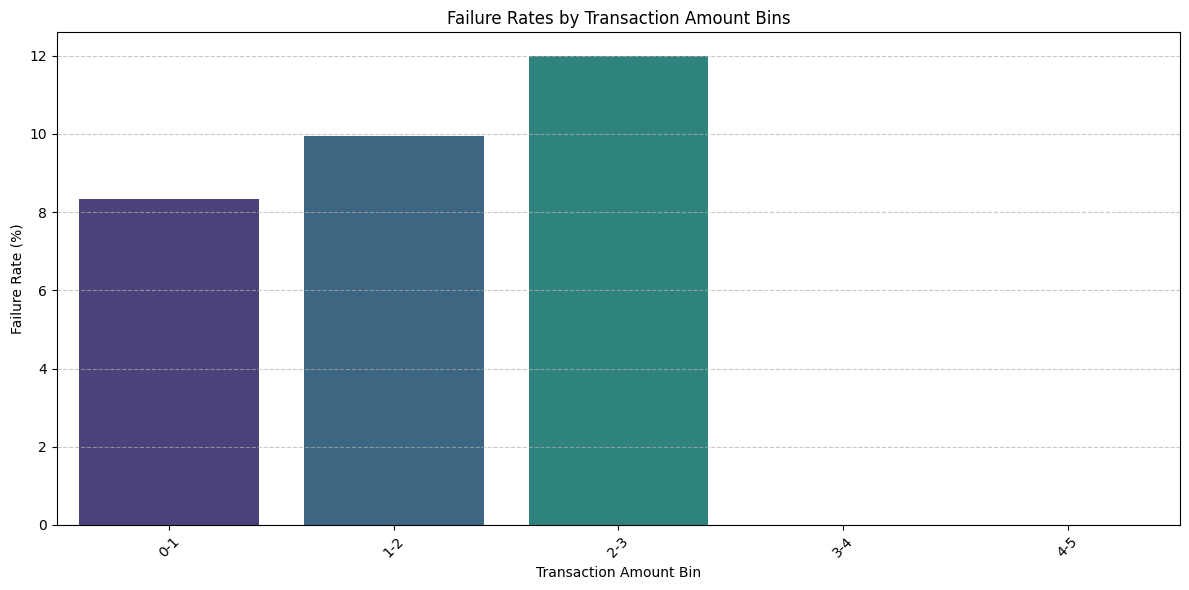

In [ ]:
# Visualize failure rates by transaction amount bin
plt.figure(figsize=(12, 6))
sns.barplot(x=failure_rates_by_amount.index, y=failure_rates_by_amount.values, palette='viridis', hue=failure_rates_by_amount.index, legend=False)
plt.title('Failure Rates by Transaction Amount Bins')
plt.xlabel('Transaction Amount Bin')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure df and 'Is_Failed' column are defined
# This check prevents redundant operations if previous cells have already run.
if 'df' not in locals() or 'Is_Failed' not in df.columns:
    # Assuming 'transactions.csv' is in the content directory
    try:
        df = pd.read_csv('/content/transactions.csv')
        # Convert 'Time' column to datetime objects if needed
        if not pd.api.types.is_datetime64_any_dtype(df['Time']):
            df['Time'] = pd.to_datetime(df['Time'])
        # Create 'Is_Failed' column
        df['Is_Failed'] = df['Transaction_Status'].apply(lambda x: 1 if x == 'Failed' else 0)
    except FileNotFoundError:
        print("Error: 'transactions.csv' not found. Please ensure the dataset is uploaded.")
        # Exit or handle error appropriately if file is missing
        raise # Re-raise the error to stop execution
    except KeyError as e:
        print(f"Error: Missing expected column in DataFrame: {e}. Please check data integrity.")
        raise
    print("DataFrame 'df' and 'Is_Failed' column initialized within this cell.")

# Calculate failure rates by location
failure_rates_by_location = df.groupby('Location')['Is_Failed'].mean() * 100

print("Failure Rates by Location:")
display(failure_rates_by_location.sort_values(ascending=False).head(10))

DataFrame 'df' and 'Is_Failed' column initialized within this cell.
Failure Rates by Location:


,Is_Failed
Location,
Coimbatore,9.933142
Hyderabad,9.568875
Tiruchengode,8.523290
Bengaluru,8.333333
Chennai,8.333333
Madurai,8.258706
Delhi,7.884615
Kochi,7.878788
Mumbai,7.581574


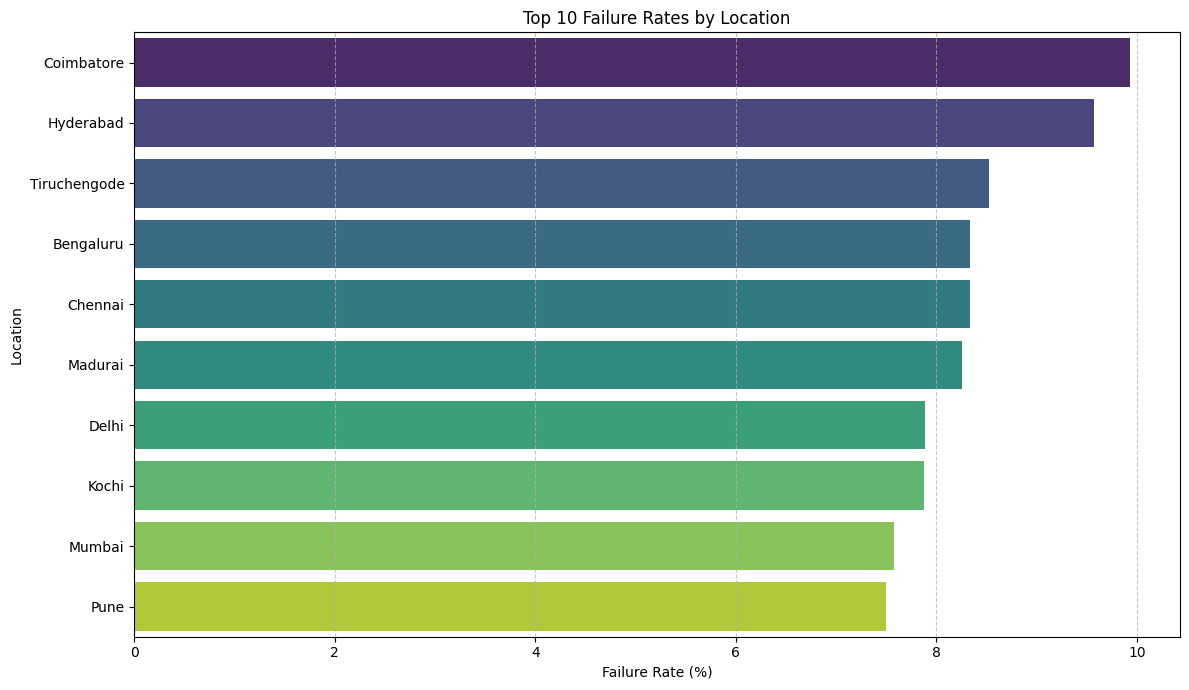

In [4]:
# Visualize failure rates by location
plt.figure(figsize=(12, 7))
sns.barplot(x=failure_rates_by_location.sort_values(ascending=False).head(10).values, y=failure_rates_by_location.sort_values(ascending=False).head(10).index, palette='viridis', hue=failure_rates_by_location.sort_values(ascending=False).head(10).index, legend=False)
plt.title('Top 10 Failure Rates by Location')
plt.xlabel('Failure Rate (%)')
plt.ylabel('Location')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()